In [1]:
import gc
from diffusers import AutoencoderKL, StableDiffusionXLControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
import torch
from controlnet_aux import OpenposeDetector
from diffusers.utils import load_image
from PIL import Image

torch.cuda.empty_cache()

/home/tejag/projects/howdy_notebook/venv/lib/python3.13/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/home/tejag/projects/howdy_notebook/venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/tejag/projects/howdy_notebook/venv/lib/python3.13/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/tejag/projects/howdy_notebook/venv/lib/python3.13/site-packages/controlnet_aux/segmen

In [2]:
from math import ceil

def flex_grid(imgs, cols):
  rows=ceil(len(imgs)/cols)

  w, h = imgs[0].size
  grid = Image.new('RGB', size=(cols*w, rows*h))

  for i, img in enumerate(imgs):
      grid.paste(img, box=(i%cols*w, i//cols*h))
  return grid

(512, 512)


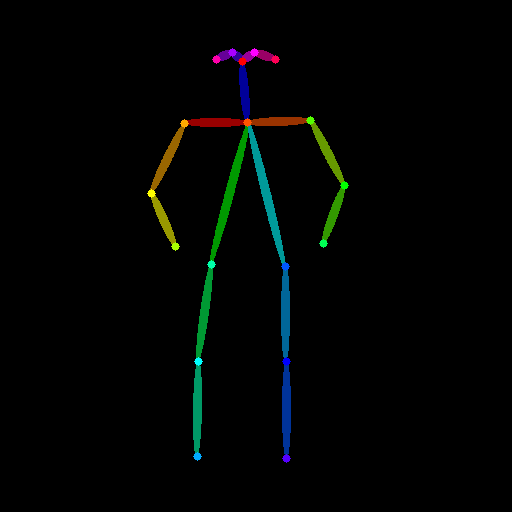

In [5]:
openpose = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")
image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/person.png"
)
openpose_image = openpose(image)
print(openpose_image.size)
openpose_image

(512, 512)


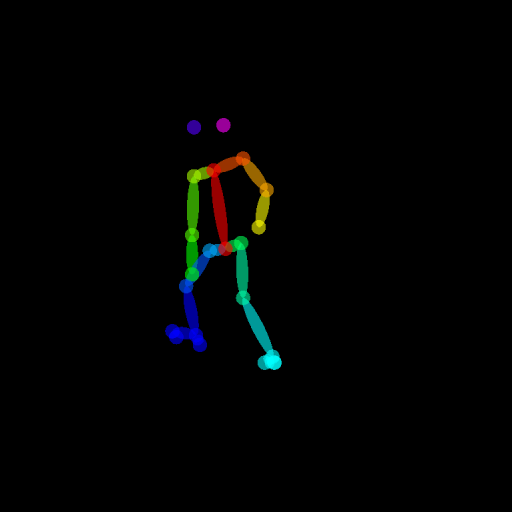

In [8]:
openpose_image=load_image('./militia/pose1.png')
print(openpose_image.size)
openpose_image

In [10]:
del openpose
gc.collect()
torch.cuda.empty_cache()

NameError: name 'openpose' is not defined

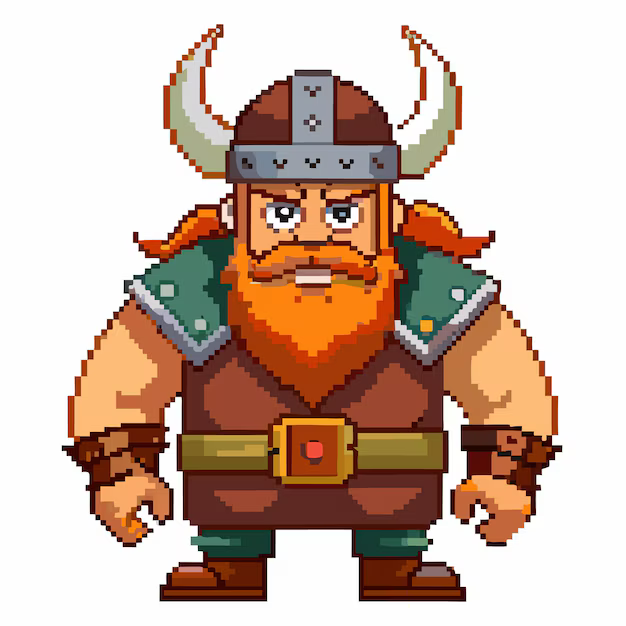

In [11]:
init_image = load_image('./militia/militia.png')
init_image

In [18]:
# Initialize ControlNet pipeline.
controlnet = ControlNetModel.from_pretrained("thibaud/controlnet-openpose-sdxl-1.0", torch_dtype=torch.float16)
pipe = StableDiffusionXLControlNetPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", controlnet=controlnet, torch_dtype=torch.float16,
)

An error occurred while trying to fetch thibaud/controlnet-openpose-sdxl-1.0: thibaud/controlnet-openpose-sdxl-1.0 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [14]:
# https://www.felixsanz.dev/articles/ultimate-guide-to-optimizing-stable-diffusion-xl
pipe.enable_sequential_cpu_offload()

# pipe.enable_model_cpu_offload()

pipe.enable_xformers_memory_efficient_attention()
pipe.enable_vae_tiling()

In [15]:
# Infer.
prompt = "Medieval barbarian warrior. brown hair. brown long beard. minimal leather clothing."
negative_prompt = "low quality, bad quality"
g = torch.Generator(device="cuda")# torch.manual_seed(97),
g.seed()
images = pipe(
    prompt, 
    negative_prompt=negative_prompt,
    num_inference_steps=25,
    num_images_per_prompt=1,
    init_image=init_image,
    #strength=0.3,
    #guidance_scale=10.,
    image=openpose_image.resize((512, 512)),
    generator=g,
).images
grid = flex_grid(images, cols=2)
grid

  0%|          | 0/25 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 26.00 MiB. GPU 0 has a total capacity of 7.66 GiB of which 40.75 MiB is free. Including non-PyTorch memory, this process has 7.06 GiB memory in use. Of the allocated memory 6.68 GiB is allocated by PyTorch, and 215.35 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [8]:
del controlnet
del pipe
gc.collect()
torch.cuda.empty_cache()

NameError: name 'controlnet' is not defined

In [ ]:
print(torch.cuda.memory_summary(device=None, abbreviated=False))

In [17]:
!pip install GPUtil

import torch
from GPUtil import showUtilization as gpu_usage
from numba import cuda

def free_gpu_cache():
    print("Initial GPU Usage")
    gpu_usage()
    
    torch.cuda.empty_cache()

    cuda.select_device(0)
    cuda.close()
    cuda.select_device(0)

    print("GPU Usage after emptying the cache")
    gpu_usage()

free_gpu_cache()

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% |  6% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  3% |  6% |
